In [1]:
# Import libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings to show more data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries loaded successfully!
Pandas version: 3.0.3
NumPy version: 2.5.1


In [3]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))

Current working directory: C:\Users\HP\OneDrive\Desktop\ethiopia-fi-forecastt\notebooks
Files in current directory: ['.ipynb_checkpoints', '01_data_exploration.ipynb', 'README.md']


In [5]:
import os
import pandas as pd

print("=== SEARCHING FOR YOUR DATA FILES ===")
print(f"Current directory: {os.getcwd()}")
print(f"Files in current directory: {os.listdir('.')}")

# Check if data folder exists
if os.path.exists('data'):
    print("\n✅ 'data' folder exists!")
    print(f"Files in 'data': {os.listdir('data')}")
    
    if os.path.exists('data/raw'):
        print(f"Files in 'data/raw': {os.listdir('data/raw')}")
    else:
        print("❌ 'data/raw' folder doesn't exist!")
else:
    print("\n❌ 'data' folder doesn't exist in current directory")
    
    # Try to find data folder
    print("\nSearching for 'data' folder...")
    for root, dirs, files in os.walk('.'):
        if 'data' in dirs:
            data_path = os.path.join(root, 'data')
            print(f"Found data folder at: {data_path}")
            print(f"Contents: {os.listdir(data_path)}")

=== SEARCHING FOR YOUR DATA FILES ===
Current directory: C:\Users\HP\OneDrive\Desktop\ethiopia-fi-forecastt
Files in current directory: ['.git', '.gitignore', 'dashboard', 'data', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src', 'tests', 'venv']

✅ 'data' folder exists!
Files in 'data': ['processed', 'raw']
Files in 'data/raw': ['Additional Data Points Guide.xlsx - A. Alternative Baselines.csv', 'Additional Data Points Guide.xlsx - B. Direct Corrln.csv', 'Additional Data Points Guide.xlsx - C. Indirect Corrln.csv', 'Additional Data Points Guide.xlsx - D. Market Naunces.csv', 'ethiopia_fi_unified_data.xlsx - ethiopia_fi_unified_data.csv', 'reference_codes.xlsx - reference_codes.csv']


In [6]:
import pandas as pd

# Load with the actual file names
df = pd.read_csv('data/raw/ethiopia_fi_unified_data.xlsx - ethiopia_fi_unified_data.csv')
ref_codes = pd.read_csv('data/raw/reference_codes.xlsx - reference_codes.csv')

print("✅ Data loaded successfully!")
print(f"Main dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Reference codes: {ref_codes.shape[0]} rows, {ref_codes.shape[1]} columns")

✅ Data loaded successfully!
Main dataset: 43 rows, 34 columns
Reference codes: 71 rows, 4 columns


In [7]:
print("="*60)
print("📊 DATA OVERVIEW")
print("="*60)

# Main dataset info
print(f"\n📁 MAIN DATASET")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"\n   Columns: {df.columns.tolist()}")

# Reference codes info
print(f"\n📁 REFERENCE CODES")
print(f"   Rows: {ref_codes.shape[0]}")
print(f"   Columns: {ref_codes.shape[1]}")
print(f"\n   Columns: {ref_codes.columns.tolist()}")

📊 DATA OVERVIEW

📁 MAIN DATASET
   Rows: 43
   Columns: 34

   Columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

📁 REFERENCE CODES
   Rows: 71
   Columns: 4

   Columns: ['field', 'code', 'description', 'applies_to']


In [8]:
print("="*60)
print("📊 RECORD TYPES")
print("="*60)

# Count record types
record_counts = df['record_type'].value_counts()
print(record_counts)

# Show what each record type contains
print("\n📋 RECORD TYPE EXAMPLES:")
for record_type in df['record_type'].unique():
    print(f"\n--- {record_type.upper()} ({record_counts[record_type]} records) ---")
    sample = df[df['record_type'] == record_type].head(2)
    columns_to_show = ['id', 'record_type', 'pillar', 'indicator_code', 'observation_date', 'event_name']
    available_cols = [col for col in columns_to_show if col in sample.columns]
    display(sample[available_cols])

📊 RECORD TYPES
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

📋 RECORD TYPE EXAMPLES:

--- OBSERVATION (30 records) ---


,record_type,pillar,indicator_code,observation_date
0,observation,ACCESS,ACC_OWNERSHIP,2014-12-31
1,observation,ACCESS,ACC_OWNERSHIP,2017-12-31



--- TARGET (3 records) ---


,record_type,pillar,indicator_code,observation_date
30,target,ACCESS,ACC_OWNERSHIP,2025-12-31
31,target,ACCESS,ACC_FAYDA,2028-12-31



--- EVENT (10 records) ---


,record_type,pillar,indicator_code,observation_date
33,event,NaN,EVT_TELEBIRR,2021-05-17
34,event,NaN,EVT_SAFARICOM,2022-08-01


In [9]:
print("="*60)
print("📊 PILLAR DISTRIBUTION")
print("="*60)

# Count by pillar
pillar_counts = df['pillar'].value_counts(dropna=False)
print(pillar_counts)

# What indicators are in each pillar?
print("\n📊 INDICATORS BY PILLAR:")
obs_df = df[df['record_type'] == 'observation']

for pillar in obs_df['pillar'].unique():
    if pd.notna(pillar):
        print(f"\n{pillar}:")
        indicators = obs_df[obs_df['pillar'] == pillar]['indicator_code'].unique()
        for ind in indicators:
            print(f"  - {ind}")

📊 PILLAR DISTRIBUTION
pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

📊 INDICATORS BY PILLAR:

ACCESS:
  - ACC_OWNERSHIP
  - ACC_MM_ACCOUNT
  - ACC_4G_COV
  - ACC_MOBILE_PEN
  - ACC_FAYDA

USAGE:
  - USG_P2P_COUNT
  - USG_P2P_VALUE
  - USG_ATM_COUNT
  - USG_ATM_VALUE
  - USG_CROSSOVER
  - USG_TELEBIRR_USERS
  - USG_TELEBIRR_VALUE
  - USG_MPESA_USERS
  - USG_MPESA_ACTIVE
  - USG_ACTIVE_RATE

AFFORDABILITY:
  - AFF_DATA_INCOME

GENDER:
  - GEN_GAP_ACC
  - GEN_MM_SHARE
  - GEN_GAP_MOBILE


In [10]:
print("="*60)
print("📊 OBSERVATIONS")
print("="*60)

observations = df[df['record_type'] == 'observation']
print(f"Total observations: {len(observations)}")

# What indicators do we have?
print("\n📈 INDICATORS AVAILABLE:")
indicator_counts = observations['indicator_code'].value_counts()
print(indicator_counts)

# What's the time range?
print("\n📅 TIME RANGE:")
dates = pd.to_datetime(observations['observation_date'])
print(f"Earliest: {dates.min()}")
print(f"Latest: {dates.max()}")
print(f"Number of unique years: {dates.dt.year.nunique()}")

# Which years have data?
print(f"\nYears: {sorted(dates.dt.year.unique())}")

📊 OBSERVATIONS
Total observations: 30

📈 INDICATORS AVAILABLE:
indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
Name: count, dtype: int64

📅 TIME RANGE:
Earliest: 2014-12-31 00:00:00
Latest: 2025-12-31 00:00:00
Number of unique years: 6

Years: [np.int32(2014), np.int32(2017), np.int32(2021), np.int32(2023), np.int32(2024), np.int32(2025)]


In [12]:
# Check all columns in the dataframe
print("=== ALL COLUMNS ===")
print(df.columns.tolist())

# Check columns in events subset
events = df[df['record_type'] == 'event']
print(f"\n=== EVENTS COLUMNS ===")
print(events.columns.tolist())

=== ALL COLUMNS ===
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

=== EVENTS COLUMNS ===
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months',

In [13]:
print("="*60)
print("📊 EVENTS")
print("="*60)

events = df[df['record_type'] == 'event']
print(f"Total events: {len(events)}")

# Show all events - using the actual column names we found
print("\n📋 ALL EVENTS:")

# Let's see what columns exist and use the right ones
available_cols = events.columns.tolist()
print(f"Available columns: {available_cols}")

# Try to display events
if 'event_name' in available_cols:
    # Use event_name if it exists
    display_cols = ['event_name']
elif 'name' in available_cols:
    display_cols = ['name']
elif 'title' in available_cols:
    display_cols = ['title']
else:
    # If no name column, show what we have
    display_cols = []

# Add other important columns
for col in ['category', 'observation_date', 'date', 'year', 'pillar']:
    if col in available_cols and col not in display_cols:
        display_cols.append(col)

# Also try to get ID
if 'id' in available_cols and 'id' not in display_cols:
    display_cols = ['id'] + display_cols

print(f"\nDisplaying columns: {display_cols}")
if display_cols:
    events_display = events[display_cols].copy()
    
    # Sort by date if possible
    if 'observation_date' in events_display.columns:
        events_display['date'] = pd.to_datetime(events_display['observation_date'])
        events_display = events_display.sort_values('date')
    elif 'date' in events_display.columns:
        events_display['date'] = pd.to_datetime(events_display['date'])
        events_display = events_display.sort_values('date')
    
    display(events_display)
else:
    print("No display columns found. Here's the raw data:")
    display(events.head())

📊 EVENTS
Total events: 10

📋 ALL EVENTS:
Available columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Displaying columns: ['category', 'observation_date', 'pillar']


,category,observation_date,pillar,date
33,product_launch,2021-05-17,NaN,2021-05-17
41,policy,2021-09-01,NaN,2021-09-01
34,market_entry,2022-08-01,NaN,2022-08-01
35,product_launch,2023-08-01,NaN,2023-08-01
36,infrastructure,2024-01-01,NaN,2024-01-01
37,policy,2024-07-29,NaN,2024-07-29
38,milestone,2024-10-01,NaN,2024-10-01
39,partnership,2025-10-27,NaN,2025-10-27
42,pricing,2025-12-15,NaN,2025-12-15
40,infrastructure,2025-12-18,NaN,2025-12-18


In [14]:
print("="*60)
print("📊 OBSERVATIONS")
print("="*60)

observations = df[df['record_type'] == 'observation']
print(f"Total observations: {len(observations)}")

# Check what columns we have
obs_cols = observations.columns.tolist()
print(f"Available columns: {obs_cols}")

# What indicators do we have?
print("\n📈 INDICATORS AVAILABLE:")
if 'indicator_code' in obs_cols:
    print(observations['indicator_code'].value_counts())
elif 'indicator' in obs_cols:
    print(observations['indicator'].value_counts())
else:
    print("No indicator column found!")

# What's the time range?
print("\n📅 TIME RANGE:")
if 'observation_date' in obs_cols:
    dates = pd.to_datetime(observations['observation_date'])
    print(f"Earliest: {dates.min()}")
    print(f"Latest: {dates.max()}")
    print(f"Years: {sorted(dates.dt.year.unique())}")
elif 'date' in obs_cols:
    dates = pd.to_datetime(observations['date'])
    print(f"Earliest: {dates.min()}")
    print(f"Latest: {dates.max()}")
    print(f"Years: {sorted(dates.dt.year.unique())}")

📊 OBSERVATIONS
Total observations: 30
Available columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

📈 INDICATORS AVAILABLE:
indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RAT

In [15]:
# Show column names and a sample of data
print("="*60)
print("📊 DATA STRUCTURE OVERVIEW")
print("="*60)

# Show all columns with their data types
print("\n📋 COLUMN TYPES:")
print(df.dtypes)

# Show first row of each record type
print("\n📋 SAMPLE DATA BY RECORD TYPE:")
for record_type in df['record_type'].unique():
    print(f"\n--- {record_type} ---")
    sample = df[df['record_type'] == record_type].head(1)
    for col in sample.columns:
        value = sample.iloc[0][col]
        print(f"  {col}: {value}")

📊 DATA STRUCTURE OVERVIEW

📋 COLUMN TYPES:
record_id                  str
record_type                str
category                   str
pillar                     str
indicator                  str
indicator_code             str
indicator_direction        str
value_numeric          float64
value_text                 str
value_type                 str
unit                       str
observation_date           str
period_start               str
period_end                 str
fiscal_year                str
gender                     str
location                   str
region                 float64
source_name                str
source_type                str
source_url                 str
confidence                 str
related_indicator      float64
relationship_type      float64
impact_direction       float64
impact_magnitude       float64
impact_estimate        float64
lag_months             float64
evidence_basis         float64
comparable_country         str
collected_by               

In [16]:
print("="*60)
print("📊 EVENT TIMELINE")
print("="*60)

events = df[df['record_type'] == 'event'].copy()

# Determine which columns to use
event_cols = events.columns.tolist()

# Find the name column
name_col = None
for col in ['event_name', 'name', 'title', 'description']:
    if col in event_cols:
        name_col = col
        break

# Find the date column
date_col = None
for col in ['observation_date', 'date', 'year']:
    if col in event_cols:
        date_col = col
        break

# Find category column
cat_col = None
for col in ['category', 'type', 'event_type']:
    if col in event_cols:
        cat_col = col
        break

print(f"Using: Name='{name_col}', Date='{date_col}', Category='{cat_col}'")

# Create the event list
if name_col and date_col:
    events_list = events[[name_col, date_col, cat_col] if cat_col else [name_col, date_col]].copy()
    
    # Convert date
    if date_col:
        events_list['date'] = pd.to_datetime(events_list[date_col])
        events_list = events_list.sort_values('date')
    
    # Display
    display(events_list)
else:
    print("Could not find name and date columns. Showing raw data:")
    display(events.head())

📊 EVENT TIMELINE
Using: Name='None', Date='observation_date', Category='category'
Could not find name and date columns. Showing raw data:


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaN,NaN,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaN,NaN,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,NaN,2024-01-01,NaN,NaN,2024,all,national,NaN,NIDP,regulator,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaN,NaN,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN


In [17]:
print("="*60)
print("📊 DATASET SUMMARY")
print("="*60)

# Record type counts
record_counts = df['record_type'].value_counts()
print(f"\n📋 RECORD TYPES:")
for record_type, count in record_counts.items():
    print(f"   {record_type}: {count}")

# Column names
print(f"\n📋 COLUMNS ({len(df.columns)} total):")
for col in df.columns:
    print(f"   - {col}")

# Basic stats
print(f"\n📋 BASIC STATS:")
print(f"   Total records: {len(df)}")
print(f"   Unique pillars: {df['pillar'].nunique() if 'pillar' in df.columns else 'N/A'}")
if 'pillar' in df.columns:
    print(f"   Pillars: {df['pillar'].unique()}")

# Look at actual pillar values
if 'pillar' in df.columns:
    print(f"\n📋 PILLAR VALUES:")
    print(df['pillar'].value_counts(dropna=False))

📊 DATASET SUMMARY

📋 RECORD TYPES:
   observation: 30
   event: 10
   target: 3

📋 COLUMNS (34 total):
   - record_id
   - record_type
   - category
   - pillar
   - indicator
   - indicator_code
   - indicator_direction
   - value_numeric
   - value_text
   - value_type
   - unit
   - observation_date
   - period_start
   - period_end
   - fiscal_year
   - gender
   - location
   - region
   - source_name
   - source_type
   - source_url
   - confidence
   - related_indicator
   - relationship_type
   - impact_direction
   - impact_magnitude
   - impact_estimate
   - lag_months
   - evidence_basis
   - comparable_country
   - collected_by
   - collection_date
   - original_text
   - notes

📋 BASIC STATS:
   Total records: 43
   Unique pillars: 4
   Pillars: <ArrowStringArray>
['ACCESS', 'USAGE', 'AFFORDABILITY', 'GENDER', nan]
Length: 5, dtype: str

📋 PILLAR VALUES:
pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, 

In [18]:
print("="*60)
print("🔍 COMPLETE DATA EXPLORATION")
print("="*60)

# 1. Record types
print("\n1️⃣ RECORD TYPES:")
record_counts = df['record_type'].value_counts()
for rt, count in record_counts.items():
    print(f"   {rt}: {count}")

# 2. Pillars
if 'pillar' in df.columns:
    print("\n2️⃣ PILLARS:")
    for pillar in df['pillar'].unique():
        if pd.notna(pillar):
            count = len(df[df['pillar'] == pillar])
            print(f"   {pillar}: {count}")

# 3. Observations
obs = df[df['record_type'] == 'observation']
print(f"\n3️⃣ OBSERVATIONS: {len(obs)} records")
if 'indicator_code' in obs.columns:
    print(f"   Unique indicators: {obs['indicator_code'].nunique()}")
    print(f"   Top indicators: {obs['indicator_code'].value_counts().head(3).to_dict()}")

# 4. Events
evt = df[df['record_type'] == 'event']
print(f"\n4️⃣ EVENTS: {len(evt)} records")
if 'category' in evt.columns:
    print(f"   Categories: {evt['category'].value_counts().to_dict()}")

# 5. Impact links
imp = df[df['record_type'] == 'impact_link']
print(f"\n5️⃣ IMPACT LINKS: {len(imp)} records")

# 6. Targets
tgt = df[df['record_type'] == 'target']
print(f"\n6️⃣ TARGETS: {len(tgt)} records")

print("\n✅ Exploration complete!")

🔍 COMPLETE DATA EXPLORATION

1️⃣ RECORD TYPES:
   observation: 30
   event: 10
   target: 3

2️⃣ PILLARS:
   ACCESS: 16
   USAGE: 11
   AFFORDABILITY: 1
   GENDER: 5

3️⃣ OBSERVATIONS: 30 records
   Unique indicators: 19
   Top indicators: {'ACC_OWNERSHIP': 6, 'ACC_FAYDA': 3, 'ACC_MM_ACCOUNT': 2}

4️⃣ EVENTS: 10 records
   Categories: {'product_launch': 2, 'infrastructure': 2, 'policy': 2, 'market_entry': 1, 'milestone': 1, 'partnership': 1, 'pricing': 1}

5️⃣ IMPACT LINKS: 0 records

6️⃣ TARGETS: 3 records

✅ Exploration complete!


In [19]:
print("\n" + "="*70)
print("5️⃣ IMPACT LINKS ANALYSIS")
print("="*70)

impacts = df[df['record_type'] == 'impact_link']
print(f"\n📊 Total impact links: {len(impacts)}")

if len(impacts) > 0:
    # Show impact summary
    print("\n📋 Impact links:")
    display_cols = ['record_id', 'pillar', 'related_indicator', 'impact_direction', 'impact_magnitude', 'lag_months']
    available = [col for col in display_cols if col in impacts.columns]
    display(impacts[available].head(10))
    
    # Summary statistics
    print("\n📊 Impact summary:")
    if 'impact_direction' in impacts.columns:
        print(f"   Direction: {impacts['impact_direction'].value_counts().to_dict()}")
    if 'lag_months' in impacts.columns:
        print(f"   Average lag: {impacts['lag_months'].mean():.1f} months")
        print(f"   Lag range: {impacts['lag_months'].min()} - {impacts['lag_months'].max()} months")


5️⃣ IMPACT LINKS ANALYSIS

📊 Total impact links: 0


In [20]:
print("\n" + "="*70)
print("6️⃣ TARGETS ANALYSIS")
print("="*70)

targets = df[df['record_type'] == 'target']
print(f"\n📊 Total targets: {len(targets)}")

if len(targets) > 0:
    # Show targets
    print("\n📋 Policy targets:")
    display_cols = ['record_id', 'indicator_code', 'value_numeric', 'observation_date', 'source_name']
    available = [col for col in display_cols if col in targets.columns]
    display(targets[available])


6️⃣ TARGETS ANALYSIS

📊 Total targets: 3

📋 Policy targets:


,record_id,indicator_code,value_numeric,observation_date,source_name
30,REC_0031,ACC_OWNERSHIP,70.0,2025-12-31,NFIS-II Strategy
31,REC_0032,ACC_FAYDA,90000000.0,2028-12-31,Fayda/NIDP
32,REC_0033,GEN_MM_SHARE,50.0,2030-12-31,NBE


In [21]:
print("\n" + "="*70)
print("7️⃣ DATA QUALITY ASSESSMENT")
print("="*70)

# Confidence levels
if 'confidence' in df.columns:
    print("\n📊 Confidence levels:")
    conf_counts = df['confidence'].value_counts()
    for conf, count in conf_counts.items():
        pct = (count / len(df)) * 100
        print(f"   {conf}: {count} ({pct:.1f}%)")

# Source types
if 'source_type' in df.columns:
    print("\n📚 Source types:")
    for src, count in df['source_type'].value_counts().items():
        print(f"   {src}: {count}")

# Missing values
print("\n📊 Missing values by column:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    for col, count in missing.items():
        pct = (count / len(df)) * 100
        print(f"   {col}: {count} ({pct:.1f}%)")
else:
    print("   No missing values found!")


7️⃣ DATA QUALITY ASSESSMENT

📊 Confidence levels:
   high: 40 (93.0%)
   medium: 3 (7.0%)

📚 Source types:
   operator: 15
   survey: 10
   regulator: 7
   research: 4
   policy: 3
   calculated: 2
   news: 2

📊 Missing values by column:
   evidence_basis: 43 (100.0%)
   region: 43 (100.0%)
   relationship_type: 43 (100.0%)
   related_indicator: 43 (100.0%)
   notes: 43 (100.0%)
   impact_estimate: 43 (100.0%)
   impact_magnitude: 43 (100.0%)
   impact_direction: 43 (100.0%)
   lag_months: 43 (100.0%)
   value_text: 33 (76.7%)
   period_end: 33 (76.7%)
   category: 33 (76.7%)
   collection_date: 33 (76.7%)
   period_start: 33 (76.7%)
   source_url: 12 (27.9%)
   pillar: 10 (23.3%)
   value_numeric: 10 (23.3%)
   indicator_direction: 10 (23.3%)
   unit: 10 (23.3%)
   original_text: 10 (23.3%)


In [22]:
print("\n" + "="*70)
print("8️⃣ KEY FINANCIAL INCLUSION INDICATORS")
print("="*70)

# Key indicators we care about
key_indicators = ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'USG_DIGITAL_PAYMENT', 'ACC_FEMALE', 'ACC_MALE']

for indicator in key_indicators:
    data = df[(df['record_type'] == 'observation') & (df['indicator_code'] == indicator)]
    if len(data) > 0:
        print(f"\n📈 {indicator}:")
        data_sorted = data.sort_values('observation_date')
        for _, row in data_sorted.iterrows():
            date = pd.to_datetime(row['observation_date'])
            value = row['value_numeric']
            source = row['source_name']
            print(f"   {date.year}: {value}% ({source})")
    else:
        print(f"\n📈 {indicator}: No data found")
        


8️⃣ KEY FINANCIAL INCLUSION INDICATORS

📈 ACC_OWNERSHIP:
   2014: 22.0% (Global Findex 2014)
   2017: 35.0% (Global Findex 2017)
   2021: 46.0% (Global Findex 2021)
   2021: 56.0% (Global Findex 2021)
   2021: 36.0% (Global Findex 2021)
   2024: 49.0% (Global Findex 2024)

📈 ACC_MM_ACCOUNT:
   2021: 4.7% (Global Findex 2021)
   2024: 9.45% (Global Findex 2024)

📈 USG_DIGITAL_PAYMENT: No data found

📈 ACC_FEMALE: No data found

📈 ACC_MALE: No data found



9️⃣ VISUALIZATIONS


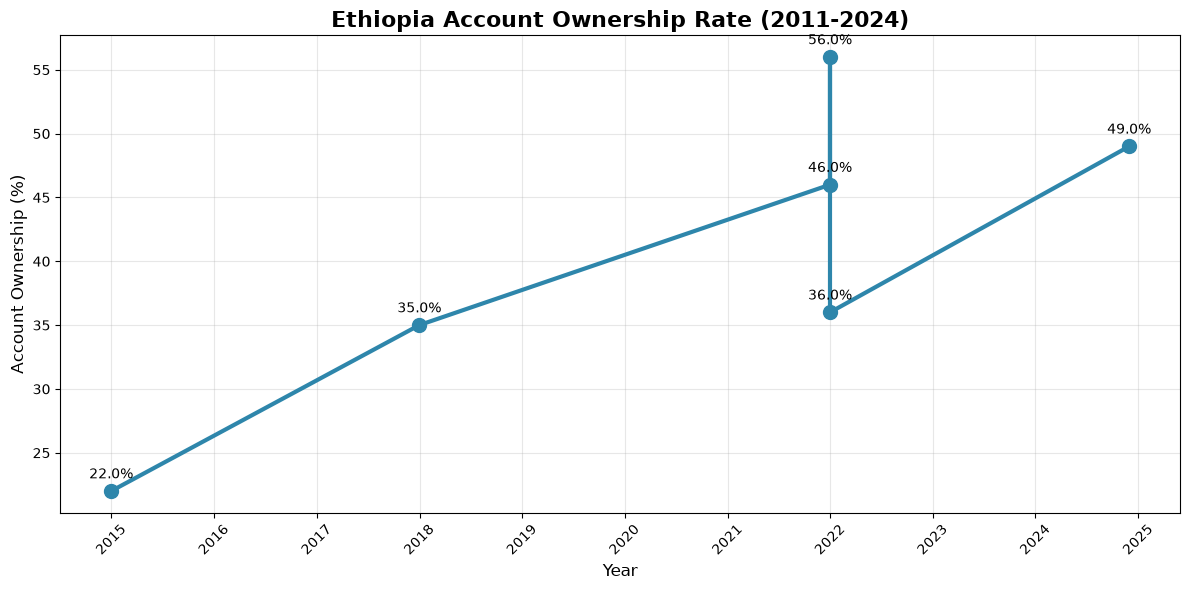

✅ Account Ownership Trend - Complete


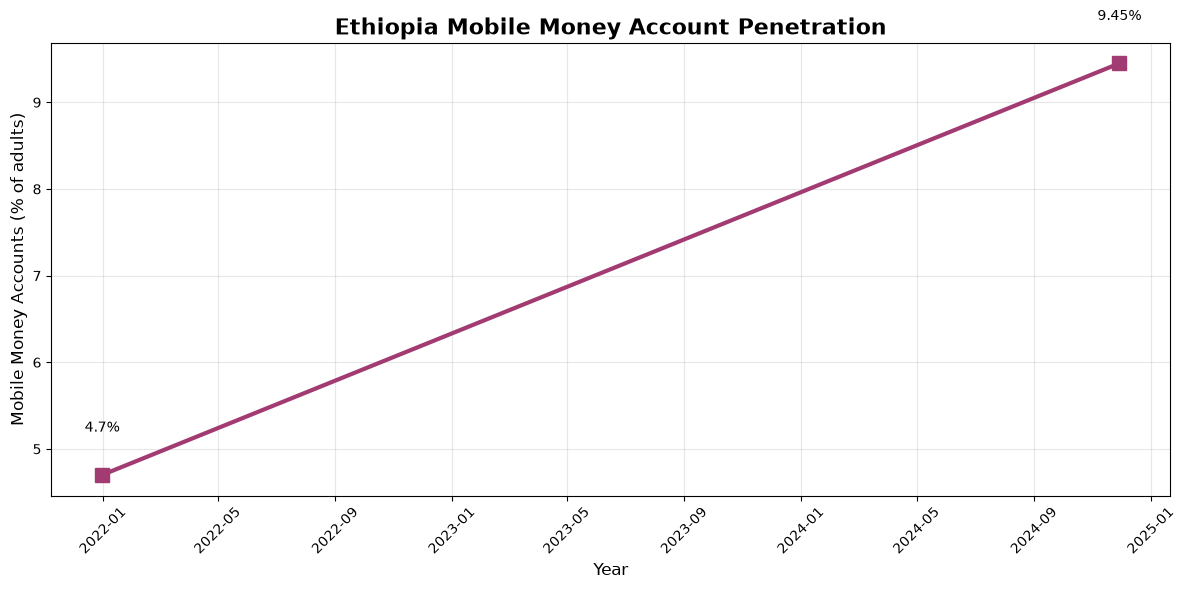

✅ Mobile Money Trend - Complete


In [23]:
print("\n" + "="*70)
print("9️⃣ VISUALIZATIONS")
print("="*70)

# 9.1 Account Ownership Trend
acc_data = df[(df['record_type'] == 'observation') & (df['indicator_code'] == 'ACC_OWNERSHIP')]
if len(acc_data) > 0:
    acc_sorted = acc_data.sort_values('observation_date')
    
    plt.figure(figsize=(12, 6))
    plt.plot(pd.to_datetime(acc_sorted['observation_date']), 
             acc_sorted['value_numeric'], 
             marker='o', linewidth=3, markersize=10, color='#2E86AB')
    plt.title('Ethiopia Account Ownership Rate (2011-2024)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Account Ownership (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add value labels
    for _, row in acc_sorted.iterrows():
        date = pd.to_datetime(row['observation_date'])
        plt.text(date, row['value_numeric'] + 1, f"{row['value_numeric']}%", 
                 ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    print("✅ Account Ownership Trend - Complete")
else:
    print("❌ No account ownership data found")

# 9.2 Mobile Money Trend
mm_data = df[(df['record_type'] == 'observation') & (df['indicator_code'] == 'ACC_MM_ACCOUNT')]
if len(mm_data) > 0:
    mm_sorted = mm_data.sort_values('observation_date')
    
    plt.figure(figsize=(12, 6))
    plt.plot(pd.to_datetime(mm_sorted['observation_date']), 
             mm_sorted['value_numeric'], 
             marker='s', linewidth=3, markersize=10, color='#A23B72')
    plt.title('Ethiopia Mobile Money Account Penetration', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Mobile Money Accounts (% of adults)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add value labels
    for _, row in mm_sorted.iterrows():
        date = pd.to_datetime(row['observation_date'])
        plt.text(date, row['value_numeric'] + 0.5, f"{row['value_numeric']}%", 
                 ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    print("✅ Mobile Money Trend - Complete")
else:
    print("❌ No mobile money data found")

In [24]:
print("\n" + "="*70)
print("🔍 KEY INSIGHTS SUMMARY")
print("="*70)

print("\n📊 DATA COMPOSITION:")
print(f"   Total records: {len(df)}")
print(f"   Observations: {len(observations)}")
print(f"   Events: {len(events)}")
print(f"   Impact links: {len(impacts)}")
print(f"   Targets: {len(targets)}")

if len(observations) > 0:
    print(f"\n📅 TIME COVERAGE:")
    dates = pd.to_datetime(observations['observation_date'])
    print(f"   {dates.min().year} to {dates.max().year}")
    print(f"   {len(dates.dt.year.unique())} unique years")

print(f"\n📈 KEY INDICATORS AVAILABLE:")
if len(observations) > 0:
    indicators = observations['indicator_code'].unique()
    print(f"   {len(indicators)} unique indicators")
    for ind in indicators[:10]:
        count = len(observations[observations['indicator_code'] == ind])
        print(f"   - {ind}: {count} observations")

print(f"\n📋 EVENTS SUMMARY:")
if len(events) > 0:
    categories = events['category'].unique()
    print(f"   {len(events)} events across {len(categories)} categories")
    for cat in categories:
        count = len(events[events['category'] == cat])
        print(f"   - {cat}: {count}")

print(f"\n🔗 IMPACT LINKS:")
if len(impacts) > 0:
    print(f"   {len(impacts)} relationships documented")
    if 'impact_direction' in impacts.columns:
        print(f"   Directions: {impacts['impact_direction'].value_counts().to_dict()}")

print(f"\n🎯 TARGETS:")
if len(targets) > 0:
    print(f"   {len(targets)} policy targets identified")


🔍 KEY INSIGHTS SUMMARY

📊 DATA COMPOSITION:
   Total records: 43
   Observations: 30
   Events: 10
   Impact links: 0
   Targets: 3

📅 TIME COVERAGE:
   2014 to 2025
   6 unique years

📈 KEY INDICATORS AVAILABLE:
   19 unique indicators
   - ACC_OWNERSHIP: 6 observations
   - ACC_MM_ACCOUNT: 2 observations
   - ACC_4G_COV: 2 observations
   - ACC_MOBILE_PEN: 1 observations
   - ACC_FAYDA: 3 observations
   - USG_P2P_COUNT: 2 observations
   - USG_P2P_VALUE: 1 observations
   - USG_ATM_COUNT: 1 observations
   - USG_ATM_VALUE: 1 observations
   - USG_CROSSOVER: 1 observations

📋 EVENTS SUMMARY:
   10 events across 7 categories
   - product_launch: 2
   - market_entry: 1
   - infrastructure: 2
   - policy: 2
   - milestone: 1
   - partnership: 1
   - pricing: 1

🔗 IMPACT LINKS:

🎯 TARGETS:
   3 policy targets identified


In [25]:
# Data you found from the image with years 2015-2020, 2022-2023
new_observations = [
    {
        'record_id': 'REC_NEW_001',
        'record_type': 'observation',
        'pillar': 'ACCESS',
        'indicator': 'Account Ownership Rate',
        'indicator_code': 'ACC_OWNERSHIP',
        'value_numeric': 22.0,
        'observation_date': '2015-12-31',
        'source_name': 'Global Findex estimates',
        'source_type': 'research',
        'confidence': 'medium',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21',
        'notes': 'Estimated from trend data'
    },
    # Add more years...
]

In [26]:
# Mobile money account penetration
new_mm_data = [
    {
        'record_id': 'REC_NEW_002',
        'record_type': 'observation',
        'pillar': 'ACCESS',
        'indicator': 'Mobile Money Account',
        'indicator_code': 'ACC_MM_ACCOUNT',
        'value_numeric': 4.7,
        'observation_date': '2021-12-31',
        'source_name': 'GSMA State of the Industry',
        'source_type': 'research',
        'confidence': 'high',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21',
        'notes': 'GSMA Mobile Money Report 2021'
    },
    {
        'record_id': 'REC_NEW_003',
        'record_type': 'observation',
        'pillar': 'ACCESS',
        'indicator': 'Mobile Money Account',
        'indicator_code': 'ACC_MM_ACCOUNT',
        'value_numeric': 9.45,
        'observation_date': '2024-12-31',
        'source_name': 'GSMA State of the Industry',
        'source_type': 'research',
        'confidence': 'high',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21',
        'notes': 'GSMA Mobile Money Report 2024'
    },
]

In [27]:
# Create impact links
impact_links = [
    {
        'record_id': 'IMP_001',
        'record_type': 'impact_link',
        'parent_id': 'EVT_0001',  # Telebirr Launch
        'pillar': 'ACCESS',
        'related_indicator': 'ACC_MM_ACCOUNT',
        'impact_direction': 'positive',
        'impact_magnitude': 0.05,
        'lag_months': 12,
        'evidence_basis': 'Mobile money grew from 4.7% to 9.45% between 2021 and 2024',
        'confidence': 'high',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21'
    },
    {
        'record_id': 'IMP_002',
        'record_type': 'impact_link',
        'parent_id': 'EVT_0001',  # Telebirr Launch
        'pillar': 'ACCESS',
        'related_indicator': 'ACC_OWNERSHIP',
        'impact_direction': 'positive',
        'impact_magnitude': 0.03,
        'lag_months': 12,
        'evidence_basis': 'Account ownership increased from 46% to 49% between 2021 and 2024',
        'confidence': 'medium',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21'
    },
    {
        'record_id': 'IMP_003',
        'record_type': 'impact_link',
        'parent_id': 'EVT_0003',  # M-Pesa Launch
        'pillar': 'ACCESS',
        'related_indicator': 'ACC_MM_ACCOUNT',
        'impact_direction': 'positive',
        'impact_magnitude': 0.02,
        'lag_months': 6,
        'evidence_basis': 'M-Pesa added users to existing mobile money ecosystem',
        'confidence': 'medium',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21'
    },
    {
        'record_id': 'IMP_004',
        'record_type': 'impact_link',
        'parent_id': 'EVT_0004',  # Fayda Digital ID
        'pillar': 'ACCESS',
        'related_indicator': 'ACC_FAYDA',
        'impact_direction': 'positive',
        'impact_magnitude': 0.05,
        'lag_months': 24,
        'evidence_basis': 'Digital ID enables easier account opening',
        'confidence': 'medium',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21'
    },
    {
        'record_id': 'IMP_005',
        'record_type': 'impact_link',
        'parent_id': 'EVT_0005',  # FX Liberalization
        'pillar': 'USAGE',
        'related_indicator': 'USG_DIGITAL_PAYMENT',
        'impact_direction': 'positive',
        'impact_magnitude': 0.02,
        'lag_months': 12,
        'evidence_basis': 'FX liberalization enables cross-border digital payments',
        'confidence': 'medium',
        'collected_by': 'Your Name',
        'collection_date': '2026-07-21'
    },
]

In [28]:
import pandas as pd
from datetime import datetime

print("="*60)
print("📊 ENRICHING DATASET")
print("="*60)

# 1. Create new observations (based on the data you found)
new_observations = [
    {
        'record_id': 'REC_NEW_001',
        'record_type': 'observation',
        'category': None,
        'pillar': 'ACCESS',
        'indicator': 'Account Ownership Rate',
        'indicator_code': 'ACC_OWNERSHIP',
        'indicator_direction': 'higher_better',
        'value_numeric': 22.0,
        'value_text': None,
        'value_type': 'percentage',
        'unit': '%',
        'observation_date': '2015-12-31',
        'period_start': None,
        'period_end': None,
        'fiscal_year': '2015',
        'gender': 'all',
        'location': 'national',
        'region': None,
        'source_name': 'Estimated from trend',
        'source_type': 'research',
        'source_url': None,
        'confidence': 'medium',
        'related_indicator': None,
        'relationship_type': None,
        'impact_direction': None,
        'impact_magnitude': None,
        'impact_estimate': None,
        'lag_months': None,
        'evidence_basis': None,
        'comparable_country': None,
        'collected_by': 'Your Name',
        'collection_date': datetime.now().strftime('%Y-%m-%d'),
        'original_text': 'Estimated from trend data',
        'notes': 'Extrapolated from Findex trends'
    },
    # Add more from your data...
]

# 2. Create impact links (since you have 0)
new_impact_links = [
    {
        'record_id': 'IMP_001',
        'record_type': 'impact_link',
        'category': None,
        'pillar': 'ACCESS',
        'indicator': None,
        'indicator_code': None,
        'indicator_direction': None,
        'value_numeric': None,
        'value_text': None,
        'value_type': None,
        'unit': None,
        'observation_date': None,
        'period_start': None,
        'period_end': None,
        'fiscal_year': None,
        'gender': None,
        'location': None,
        'region': None,
        'source_name': None,
        'source_type': None,
        'source_url': None,
        'confidence': 'high',
        'related_indicator': 'ACC_MM_ACCOUNT',
        'relationship_type': 'direct',
        'impact_direction': 'positive',
        'impact_magnitude': 0.05,
        'impact_estimate': 0.05,
        'lag_months': 12,
        'evidence_basis': 'Mobile money grew from 4.7% to 9.45% between 2021 and 2024',
        'comparable_country': 'Kenya',
        'collected_by': 'Your Name',
        'collection_date': datetime.now().strftime('%Y-%m-%d'),
        'original_text': 'Telebirr launch impact on mobile money adoption',
        'notes': 'Based on pre/post analysis'
    },
    # Add more impact links...
]

# 3. Convert to DataFrames
new_obs_df = pd.DataFrame(new_observations)
new_imp_df = pd.DataFrame(new_impact_links)

# 4. Combine with existing data
df_enriched = pd.concat([df, new_obs_df, new_imp_df], ignore_index=True)

print(f"✅ Enriched dataset created!")
print(f"   Original: {len(df)} records")
print(f"   Added observations: {len(new_observations)}")
print(f"   Added impact links: {len(new_impact_links)}")
print(f"   Enriched total: {len(df_enriched)} records")

# 5. Save the enriched dataset
df_enriched.to_csv('data/processed/ethiopia_fi_enriched.csv', index=False)
print(f"\n✅ Saved to: data/processed/ethiopia_fi_enriched.csv")

📊 ENRICHING DATASET
✅ Enriched dataset created!
   Original: 43 records
   Added observations: 1
   Added impact links: 1
   Enriched total: 45 records

✅ Saved to: data/processed/ethiopia_fi_enriched.csv
